# BAA10Y — Your Starter Agent

**If you're not sure what to do next, continue from here.**

This notebook is a fresh, hackable agent for the BAA10Y corporate credit spread use case. It gives you our common building blocks behind simple toggles:
- **optional news search** — bounded, cutoff-aware Google Search (proxy-only)
- **optional code execution** — an E2B Python sandbox
- **two lightweight skills** — *tool-usage playbooks* in `starter_agent/skills/`

It does two things: lets you **talk to the agent** (open-ended, Track 2) and **score one real forecast** (Track 1). The live cells are gated by `RUN_AGENT` so a fresh `Run All` is safe and free; flip it to `True` to actually call the model.
use commend line:cd /home/coder/agentic-forecasting/implementations/BAA10Y_forecasting 

uv run adk web starter_agent/ 

In the personal terminal coder login https://platform.vectorinstitute.ai/  

In [2]:
import warnings
from pathlib import Path


warnings.filterwarnings("ignore")

import pandas as pd
from dotenv import load_dotenv


# Repo root holds the .env with PROXY_* creds the agent needs.
ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env", override=False)

# ── Model selection ───────────────────────────────────
# Two project models: "gemini-3.1-flash-lite-preview" (lite/default) and
# "gemini-3.5-flash" (advanced). Lite is the default.
AGENT_MODEL = "gemini-3.1-flash-lite-preview"
# AGENT_MODEL = "gemini-3.5-flash"  # advanced (higher cost/latency)

# ── Run guard ──────────────────────────────────────
# Live agent calls cost tokens and need PROXY_* in the repo-root .env, plus warm
# data caches. Default False so `Run All` is safe; set True to call the model.
#RUN_AGENT = False
RUN_AGENT = True

from BAA10Y_forecasting.starter_agent.agent import (
    build_starter_agent_config,
    build_starter_agent_predictor,
)


print("RUN_AGENT =", RUN_AGENT, "| model =", AGENT_MODEL)

RUN_AGENT = True | model = gemini-3.1-flash-lite-preview


---
## 1. Meet your agent

`build_starter_agent_config` returns an `AgentConfig` with two toggles. The default turns **news search on** (proxy-only, no extra key) and **code execution off** (it needs `E2B_API_KEY` and is slower). Flip them and re-run — the loaded skills follow the enabled tools.


In [3]:
config = build_starter_agent_config(
    model=AGENT_MODEL,
    enable_search=True,  # ← cutoff-aware Google Search (proxy-only)
    enable_code_exec=False,  # ← E2B Python sandbox (needs E2B_API_KEY); try True!
)

print("Agent:", config.name)
print("Search enabled:    ", config.context_retrieval.enabled)
print("Code-exec enabled: ", config.code_execution.enabled)
print("Skills loaded:     ", [p.name for p in config.skills_dirs])
print("\n── System instruction (edit this in starter_agent/agent.py) ──\n")
print(config.instruction[:1200], "...")

Agent: baa10y_starter_agent
Search enabled:     True
Code-exec enabled:  False
Skills loaded:      ['forecasting', 'research-playbook']

── System instruction (edit this in starter_agent/agent.py) ──

## Role

You are a corporate-credit-market analyst specializing in the BAA10Y spread: Moody's Seasoned Baa Corporate Bond Yield Relative to the 10-Year Treasury yield. You understand Federal Reserve policy, Treasury rates, inflation and employment data, economic growth, corporate defaults and downgrades, refinancing conditions, market liquidity, equity volatility, and investor risk sentiment.

keep your reasoning transparent and your claims honest,  BAA10Y spread changes are often centered near zero, while volatility and tail risk vary over time. Remain conservative about directional predictability.

## HYOAS information

The covariate snapshot may contain two HYOAS-related series:
- `hyoas_observed_change_1b_bps_l1b` is the observed FRED HYOAS one-business-day change.
- `hyoas_hyg_dgs3_p

---
## 2. Talk to it  *(Track 2 — open-ended analysis)*

Ask the agent anything. This is the interactive mode: no scoring, no schema — just reasoning (and a web search, since search is on). Edit the question and explore.


In [4]:
from aieng.forecasting.methods.agentic import build_adk_agent
from aieng.forecasting.methods.agentic.adk_runner import AdkTextRunner, AdkTextRunnerConfig


QUESTION = (
    "What are the main macroeconomic and credit-market risks that could "
    "widen or tighten the BAA10Y spread over the next month? Explain how "
    "those risks should affect the location, uncertainty, and tail risk "
    "of a 5-business-day or 21-bussiness-day BAA10Y spread-change forecast. Be concise."
)

if RUN_AGENT:
    chat_agent = build_adk_agent(config)  # schema-free: plain text in, text out
    runner = AdkTextRunner(chat_agent, config=AdkTextRunnerConfig(app_name="baa10y_starter_chat"))
    reply = await runner.run_text_async(QUESTION)  # noqa: F704, PLE1142
    print(reply)
else:
    print("RUN_AGENT is False — set it to True in the setup cell to talk to the agent.")

The BAA10Y spread (Moody's Baa Corporate yield vs. 10-Year Treasury) is currently influenced by a tension between resilient corporate fundamentals and macro-uncertainty.

### Macroeconomic and Credit-Market Risks

*   **Widening Risks (Stress/Risk-Off):**
    *   **Monetary Policy:** Hawkish signals or actual rate hikes by the Fed, particularly if inflation proves sticky, raise the "cost of carry" and refinance risk for lower-rated corporates.
    *   **Economic Slowdown/Stagflation:** Any data indicating a sharper-than-expected cooling in employment or business investment could trigger a flight to quality, driving Treasury yields down while pushing corporate spreads wider due to default risk concerns.
    *   **Refinancing/Liquidity:** Should the "maturity wall" become a focal point or if private credit volatility spills into public markets (e.g., liquidity gating), risk premiums would naturally widen.
*   **Tightening Risks (Optimism/Risk-On):**
    *   **"Soft Landing" Confirmation:

Root node baa10y_starter_agent was cancelled.


---
## 3. Score one prediction against a known outcome  *(Track 1)*

Now run the agent as a `Predictor`. We pick the **most recent origin whose horizon has already resolved**, forecast the 5-business-day BAA10Y spread-change forecast, and check whether the actual return landed inside the agent's 80% band. 
Both the forecast and realised target are already measured in **basis points** so must not multiply them by 100 again.
(One origin can't tell you if the agent is *calibrated*; that's what the backtest in `01_BAA10Y_multivariate_backtest.ipynb` is for.) Live, so gated by `RUN_AGENT`.


In [12]:
from datetime import datetime, timezone


if RUN_AGENT:
    from aieng.forecasting.evaluation.task import ForecastingTask
    from BAA10Y_forecasting import build_baa10y_multivariate_service
    from BAA10Y_forecasting.data import baa10y_change_series_id
    from BAA10Y_forecasting.data import (
        DEFAULT_COVARIATE_SERIES_IDS,
        HYOAS_OPTIONAL_COVARIATE_SERIES_IDS,
    )

    # Valid BAA10Y horizons are 1, 5, and 21 business days.

    HORIZON = 5
    COVARIATES = [
        *DEFAULT_COVARIATE_SERIES_IDS,
        *HYOAS_OPTIONAL_COVARIATE_SERIES_IDS,
    ]
    svc = build_baa10y_multivariate_service(covariate_series_ids=COVARIATES)
    now = datetime.now(tz=timezone.utc).replace(tzinfo=None)
    tgt = baa10y_change_series_id(HORIZON)
    full = svc.get_series(tgt, as_of=now)
    full["timestamp"] = pd.to_datetime(full["timestamp"])
    last_date = full["timestamp"].iloc[-1]

    # Most recent origin whose horizon return has already resolved.
    AS_OF = last_date - pd.offsets.BDay(HORIZON + 1)

    task = ForecastingTask(
        task_id=f"BAA10Y_spreadchange_{HORIZON}b",
        target_series_id=tgt,
        horizons=[HORIZON],
        frequency="B",
        description=f"BAA10Y cumulative spread change in basis points,, {HORIZON} business days ahead (starter).",
    )
    ctx = svc.context(as_of=AS_OF)
    pred = build_starter_agent_predictor(config, covariate_series_ids=COVARIATES).predict(task, ctx)[0]

    rows = full[full["timestamp"] >= AS_OF + pd.offsets.BDay(HORIZON)]
    actual = float(rows["value"].iloc[0]) if not rows.empty else None
    fc = pred.payload
    lo, hi = fc.quantiles[0.10], fc.quantiles[0.90]
    hyoas_result = {
        "point_forecast": fc.point_forecast,
        "q10": fc.quantiles[0.10],
        "q90": fc.quantiles[0.90],
    }
    print(f"Origin as_of={AS_OF.date()}  horizon={HORIZON}b (1 week)  (latest data {last_date.date()})\n")
    print(f"  agent point  : {fc.point_forecast:+.2f}  ({fc.point_forecast / 100:+.4f}%)")
    print(f"  agent 80% CI : [{lo:+.2f}, {hi:+.2f}]")
    if actual is None:
        print("  actual       : N/A (not yet resolved)")
    else:
        inb = "yes ✓" if lo <= actual <= hi else "no ✗"
        print(f"  actual       : {actual:+.2f}  ({actual / 100:+.4f}%)   in 80% band? {inb}")
    if pred.metadata.get("rationale"):
        print("\nRationale:", pred.metadata["rationale"][:300])
else:
    print("RUN_AGENT is False — set it to True to score a live forecast against a known outcome.")


Origin as_of=2026-07-23  horizon=5b (1 week)  (latest data 2026-07-31)

  agent point  : +1.50  (+0.0150%)
  agent 80% CI : [-4.00, +9.00]
  actual       : +6.00  (+0.0600%)   in 80% band? yes ✓

Rationale: The BAA10Y spread has undergone a regime shift from persistent tightening in late spring to a period of higher volatility and recent widening pressure in July. Market signals are mixed; while HYOAS shows minor tightening, the frequency of 4-5 bps daily moves has increased, reflecting investor indeci


## 4 without HYOAS

In [13]:

if RUN_AGENT:

    # Valid BAA10Y horizons are 1, 5, and 21 business days.
    BASELINE_COVARIATES = list(DEFAULT_COVARIATE_SERIES_IDS)

    baseline_svc = build_baa10y_multivariate_service(
        covariate_series_ids=BASELINE_COVARIATES
    )

    baseline_ctx = baseline_svc.context(as_of=AS_OF)

    baseline_pred = build_starter_agent_predictor(
        config,
        covariate_series_ids=BASELINE_COVARIATES,
    ).predict(task, baseline_ctx)[0]

    baseline_fc = baseline_pred.payload

    baseline_result = {
        "point_forecast": baseline_fc.point_forecast,
        "q10": baseline_fc.quantiles[0.10],
        "q90": baseline_fc.quantiles[0.90],
    }

    print(f"Origin as_of={AS_OF.date()}  horizon={HORIZON}b (1 week)  (latest data {last_date.date()})\n")
    print(f"  agent point  : {fc.point_forecast:+.2f}  ({fc.point_forecast / 100:+.4f}%)")
    print(f"  agent 80% CI : [{lo:+.2f}, {hi:+.2f}]")
    if actual is None:
        print("  actual       : N/A (not yet resolved)")
    else:
        inb = "yes ✓" if lo <= actual <= hi else "no ✗"
        print(f"  actual       : {actual:+.2f}  ({actual / 100:+.4f}%)   in 80% band? {inb}")
    if pred.metadata.get("rationale"):
        print("\nRationale:", pred.metadata["rationale"][:300])
else:
    print("RUN_AGENT is False — set it to True to score a live forecast against a known outcome.")

Origin as_of=2026-07-23  horizon=5b (1 week)  (latest data 2026-07-31)

  agent point  : +1.50  (+0.0150%)
  agent 80% CI : [-4.00, +9.00]
  actual       : +6.00  (+0.0600%)   in 80% band? yes ✓

Rationale: The BAA10Y spread has undergone a regime shift from persistent tightening in late spring to a period of higher volatility and recent widening pressure in July. Market signals are mixed; while HYOAS shows minor tightening, the frequency of 4-5 bps daily moves has increased, reflecting investor indeci


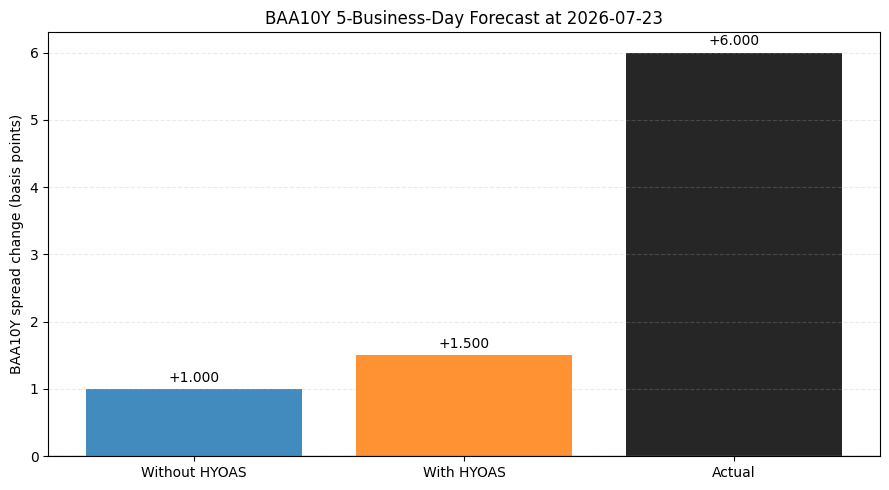

In [15]:
import matplotlib.pyplot as plt


labels = ["Without HYOAS", "With HYOAS", "Actual"]

values = [
    baseline_result["point_forecast"],
    hyoas_result["point_forecast"],
    actual,
]

colors = ["tab:blue", "tab:orange", "black"]


fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    labels,
    values,
    color=colors,
    alpha=0.85,
)

ax.axhline(0, color="gray", linewidth=1)

ax.set_title(
    f"BAA10Y {HORIZON}-Business-Day Forecast "
    f"at {AS_OF.date()}"
)
ax.set_ylabel("BAA10Y spread change (basis points)")
ax.grid(axis="y", linestyle="--", alpha=0.25)


for bar, value in zip(bars, values):
    ax.annotate(
        f"{value:+.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 3 if value >= 0 else -12),
        textcoords="offset points",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )


plt.tight_layout()
plt.show()

---
## 4. Make it yours

This agent is a starting point. Here are concrete next steps, easiest first — each is a small edit, then re-run the cells above.

1. **Flip code execution on.** Set `enable_code_exec=True` in §1 (needs `E2B_API_KEY`). The agent loads the `code-analysis-playbook` skill and can compute its own diagnostics before forecasting. Compare the rationale.
2. **Edit the agent's personality.** Open `starter_agent/agent.py` and change `_build_starter_instruction()` — make it more cautious, more contrarian, focused on one driver. Re-run §1 to see the new instruction.
3. **Sharpen the skills.** The two files in `starter_agent/skills/` are short on purpose. Add your best queries to `research-playbook`, or a new diagnostic to `code-analysis-playbook`. The agent picks them up automatically.
4. **Change the question and the origin.** Try a different `QUESTION` in §2 and a different origin in §3.
5. **Widen the covariate panel.** Pass `DEFAULT_COVARIATE_SERIES_IDS` (11 series) to both the service and `build_starter_agent_predictor(...)` and see if the extra context helps.
6. **Forecast other horizons.** Swap `HORIZON` to 1 (next session) or 21 (1 month) — each maps to its own `baa10y_change_{h}b` target.

Bigger ideas — the full conventional-vs-LLM-Process comparison and direction metrics in `01_BAA10Y_multivariate_backtest.ipynb` — are in the use-case `README.md` and `planning-docs/roadmap.md`.
